<a href="https://colab.research.google.com/github/Khushmandeep-Kaur-Dhaliwal/-project-credit-card-fraud-detection-of-ml/blob/main/credit_card_fraud_detection_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')


**Load Dataset**

In [ ]:
fraud = pd.read_csv('/content/fraudTest.csv').sample(50000, random_state=42)

In [ ]:
fraud.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
119106,119106,2020-08-02 07:55:28,377895991033232,"fraud_Bahringer, Schoen and Corkery",shopping_pos,1.07,Kimberly,Myers,F,6881 King Isle Suite 228,...,41.4682,-72.5751,5438,"Librarian, academic",1964-11-17,cf581d75ccc9ba838a05dec8bfa78b5b,1375430128,41.240083,-71.837788,0
179292,179292,2020-08-23 14:05:16,30364087349027,"fraud_Romaguera, Wehner and Tromp",kids_pets,94.99,Samuel,Sandoval,M,0005 Morrison Land,...,35.8896,-96.0887,7163,Fitness centre manager,1982-02-05,b1bfaf13224da41f422db483fd810dd7,1377266716,35.156537,-95.806648,0
540729,540729,2020-12-28 16:22:29,30328384440870,fraud_Berge-Hills,kids_pets,31.28,Helen,Campbell,F,182 Sergio Summit Apt. 129,...,40.0290,-93.1607,602,Cytogeneticist,1954-07-14,cde9fc0136873645778d0ad8817db655,1388247749,39.888665,-93.106804,0
374360,374360,2020-11-14 10:44:50,30364087349027,"fraud_Connelly, Reichert and Fritsch",gas_transport,73.06,Samuel,Sandoval,M,0005 Morrison Land,...,35.8896,-96.0887,7163,Fitness centre manager,1982-02-05,90b8429191e5c83df1afba4e5db4d61e,1384425890,36.734101,-96.737345,0
314574,314574,2020-10-19 01:50:09,4198470814557,fraud_Kuphal-Predovic,misc_net,9.99,Christie,Williamson,F,519 Jerry Views,...,41.4768,-95.3509,2036,Engineering geologist,1971-08-20,e4893795b6b3e41667129b9ed13b9650,1382147409,40.922072,-94.899388,0


In [ ]:
fraud.shape

(50000, 23)

In [ ]:
fraud.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 119106 to 316947
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             50000 non-null  int64  
 1   trans_date_trans_time  50000 non-null  object 
 2   cc_num                 50000 non-null  int64  
 3   merchant               50000 non-null  object 
 4   category               50000 non-null  object 
 5   amt                    50000 non-null  float64
 6   first                  50000 non-null  object 
 7   last                   50000 non-null  object 
 8   gender                 50000 non-null  object 
 9   street                 50000 non-null  object 
 10  city                   50000 non-null  object 
 11  state                  50000 non-null  object 
 12  zip                    50000 non-null  int64  
 13  lat                    50000 non-null  float64
 14  long                   50000 non-null  float64
 15  c

In [ ]:
fraud.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,277479.693040,4.163250e+17,69.651861,48873.736620,38.557113,-90.226246,8.590204e+04,1.380667e+09,38.559357,-90.222334,0.003900
std,160658.364811,1.307482e+18,138.133222,26805.671512,5.060717,13.707673,2.917383e+05,5.209059e+06,5.090028,13.719857,0.062329
min,2.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.038107,-166.646643,0.000000
25%,138769.500000,1.800429e+14,9.640000,26237.000000,34.703200,-96.809400,7.320000e+02,1.376024e+09,34.799022,-96.882277,0.000000
50%,276832.500000,3.521417e+15,47.720000,48193.000000,39.376400,-87.591700,2.395000e+03,1.380723e+09,39.383991,-87.444497,0.000000
75%,416519.500000,4.651007e+15,83.422500,72042.000000,41.948800,-80.175200,1.940800e+04,1.385862e+09,41.978842,-80.266257,0.000000
max,555710.000000,4.992346e+18,7587.230000,99783.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-67.032317,1.000000


In [ ]:
fraud.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
fraud.duplicated().sum()

np.int64(0)

In [ ]:
fraud['category'] = fraud['category'].astype('category').cat.codes
fraud['gender'] = fraud['gender'].astype('category').cat.codes

**EDA**

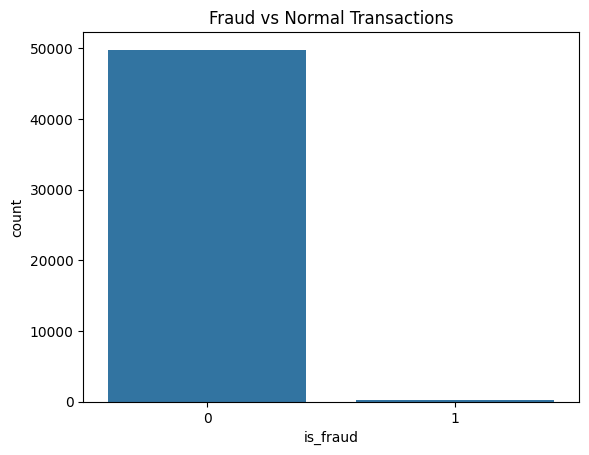

In [ ]:
sns.countplot(x='is_fraud', data=fraud)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [ ]:
fraud_count = fraud['is_fraud'].value_counts()
print(fraud_count)

print("Fraud Percentage:", (fraud_count[1]/len(fraud))*100)

is_fraud
0    49805
1      195
Name: count, dtype: int64
Fraud Percentage: 0.38999999999999996


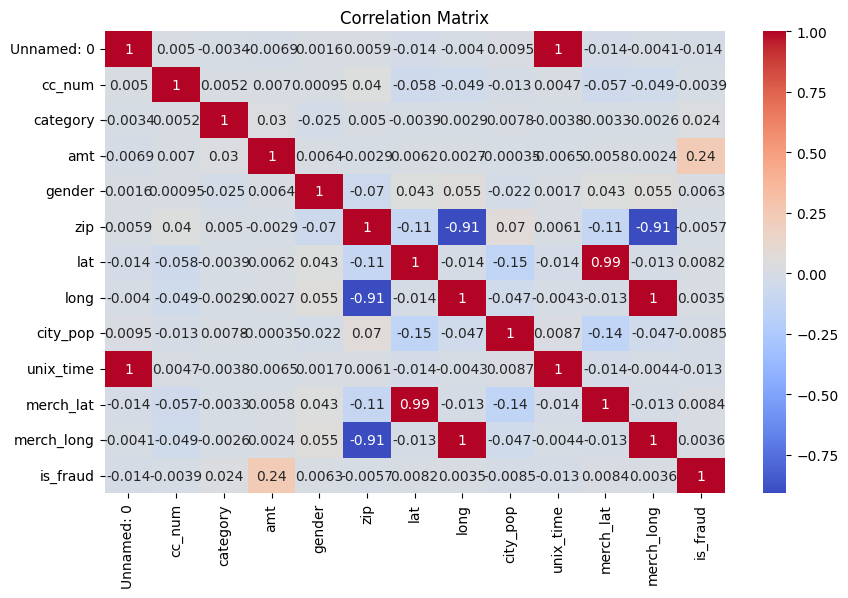

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(fraud.corr(numeric_only=True), cmap='coolwarm', annot = True)
plt.title("Correlation Matrix")
plt.show()

**Data Preprocessing**

In [ ]:
fraud = fraud.drop(['Unnamed: 0', 'trans_date_trans_time', 'merchant', 'first', 'last',
              'street', 'city', 'state', 'zip', 'job', 'dob'], axis=1, errors='ignore')

In [ ]:
fraud = fraud[['amt', 'category', 'gender', 'lat', 'long', 'city_pop', 'is_fraud']]

**Split Features**

In [ ]:
X = fraud.drop('is_fraud', axis=1)
y = fraud['is_fraud']

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train Logistic Regression Model**

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

**Predictions**

In [ ]:
y_pred = model.predict(X_test)

**Model Evaluation**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9955


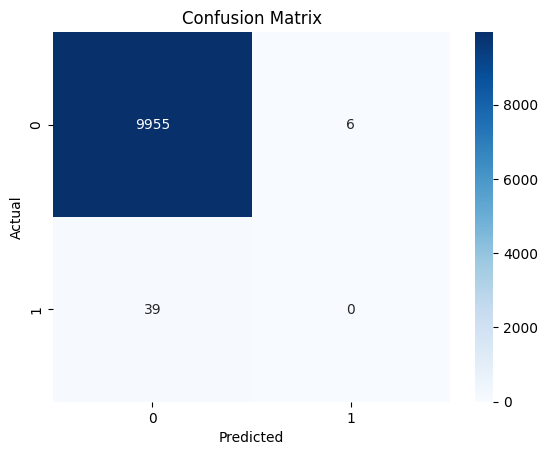

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9961
           1       0.00      0.00      0.00        39

    accuracy                           1.00     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.99      1.00      0.99     10000

